# Fundus Tumor Classification
**Model:** EfficientNet-B0 (Transfer Learning)  
**Dataset:** Ultra-Wide Fundus Images for Tumor Diagnosis  
**Classes:** Normal · CH · CO · RB · RCH · UM

In [1]:
# ── Cell 1: Check GPU ─────────────────────────────────────────────────────────
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU found — go to Runtime → Change runtime type → T4 GPU')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [2]:
# ── Cell 2: Install Dependencies & Download Dataset ──────────────────────────
!pip install -q kagglehub scikit-learn seaborn

import kagglehub
from pathlib import Path
import shutil
import os

# Download the dataset
print('Downloading Fundus Tumor Dataset...')
dataset_path = kagglehub.dataset_download("nikitamanaenkov/ultra-wide-fundus-images-for-tumor-diagnosis")
print(f"✓ Dataset downloaded to: {dataset_path}")

# List downloaded files
print("\nDataset structure:")
for item in sorted(os.listdir(dataset_path)):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        count = len(os.listdir(item_path))
        print(f"  {item:<40} ({count} files)")
    else:
        print(f"  {item}")

100%|██████████| 1.83G/1.83G [00:09<00:00, 198MB/s]

Extracting files...


✓ Dataset downloaded to: /root/.cache/kagglehub/datasets/nikitamanaenkov/ultra-wide-fundus-images-for-tumor-diagnosis/versions/3

Dataset structure:
  data                                     (6 files)


In [3]:
# ── Cell 3: Organize Data into Training/Testing Split ────────────────────────
import random
from pathlib import Path
import shutil
import os

# The kagglehub downloads to a read-only cache location
# We need to explore and find where the actual images are
DATA_DIR = Path(dataset_path)
TRAIN_DIR = Path('/content/fundus_data/Training')
TEST_DIR = Path('/content/fundus_data/Testing')

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG', '.tiff', '.bmp', '.tif'}

print(f"Dataset downloaded to: {DATA_DIR}")
print(f"\nExploring dataset structure...")

# Recursively find all directories containing images
def find_image_dirs(root_path, max_depth=3, current_depth=0):
    """Recursively find directories that contain image files"""
    result = {}
    if current_depth >= max_depth:
        return result

    try:
        for item in root_path.iterdir():
            if item.is_dir():
                # Check if this directory contains images
                images = [f for f in item.iterdir() if f.is_file() and f.suffix in IMAGE_EXTS]
                if images:
                    result[item.name] = (item, len(images))
                # Recursively check subdirectories
                result.update(find_image_dirs(item, max_depth, current_depth + 1))
    except PermissionError:
        pass

    return result

class_dirs = find_image_dirs(DATA_DIR)

# Filter out Training/Testing if they already exist in the source
class_dirs = {k: v for k, v in class_dirs.items()
              if k not in ['Training', 'Testing', 'model_output', 'results']}

if not class_dirs:
    print(f"\n❌ No image folders found!")
    print(f"\nLet's check what's in {DATA_DIR}:")
    for item in DATA_DIR.iterdir():
        print(f"  {item.name}")
    raise FileNotFoundError(f"No image folders found. Check the dataset structure above.")

print(f"\nFound {len(class_dirs)} classes:")
for cls_name, (cls_path, count) in sorted(class_dirs.items()):
    print(f"  {cls_name:<45} {count:>4} images")

# Create train/test split (80/20)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nSplitting into Train/Test (80/20) at {TRAIN_DIR.parent}...")
for class_name, (class_path, _) in sorted(class_dirs.items()):
    images = [f for f in class_path.iterdir() if f.is_file() and f.suffix in IMAGE_EXTS]
    random.seed(42)  # For reproducibility
    random.shuffle(images)

    split_idx = int(len(images) * 0.8)
    train_imgs, test_imgs = images[:split_idx], images[split_idx:]

    train_class_dir = TRAIN_DIR / class_name
    test_class_dir = TEST_DIR / class_name
    train_class_dir.mkdir(exist_ok=True)
    test_class_dir.mkdir(exist_ok=True)

    for img in train_imgs:
        shutil.copy2(img, train_class_dir / img.name)
    for img in test_imgs:
        shutil.copy2(img, test_class_dir / img.name)

    print(f"  {class_name:<45} Train: {len(train_imgs):>4} | Test: {len(test_imgs):>4}")

print("\n" + "="*70)
print("✓ Dataset split complete!")
print("="*70)

Dataset downloaded to: /root/.cache/kagglehub/datasets/nikitamanaenkov/ultra-wide-fundus-images-for-tumor-diagnosis/versions/3

Exploring dataset structure...

Found 6 classes:
  Choroidal Hemangioma (CH)                       71 images
  Choroidal Osteoma (CO)                          80 images
  Normal                                        1354 images
  Retinal Capillary Hemangioma (RCH)             186 images
  Retinoblastoma (RB)                            255 images
  Uveal Melanoma (UM)                             85 images

Splitting into Train/Test (80/20) at /content/fundus_data...
  Choroidal Hemangioma (CH)                     Train:   56 | Test:   15
  Choroidal Osteoma (CO)                        Train:   64 | Test:   16
  Normal                                        Train: 1083 | Test:  271
  Retinal Capillary Hemangioma (RCH)            Train:  148 | Test:   38
  Retinoblastoma (RB)                           Train:  204 | Test:   51
  Uveal Melanoma (UM)               

In [4]:
# ── Cell 4: Imports & Config ──────────────────────────────────────────────────
import json, time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Config
SAVE_DIR = Path('/content/model_output')
SAVE_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-4
PATIENCE = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device     : {DEVICE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs     : {EPOCHS}')
print(f'Save dir   : {SAVE_DIR}')

Device     : cuda
Batch size : 64
Epochs     : 20
Save dir   : /content/model_output


In [5]:
# ── Cell 5: Transforms & Datasets ────────────────────────────────────────────
# Verify directories exist
if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(f"Training or Testing directory not found! Run Cell 3 first.")

train_classes = [d for d in TRAIN_DIR.iterdir() if d.is_dir()]
test_classes = [d for d in TEST_DIR.iterdir() if d.is_dir()]

if not train_classes or not test_classes:
    raise FileNotFoundError(f"No class folders found in Training/Testing directories! Run Cell 3 first.")

print(f"✓ Found {len(train_classes)} training classes and {len(test_classes)} testing classes")

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = ImageFolder(TEST_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f'Train  : {len(train_dataset)} images')
print(f'Val    : {len(val_dataset)} images')
print(f'Classes: {train_dataset.classes}')

# Save class names
with open(SAVE_DIR / 'classes.json', 'w') as f:
    json.dump(train_dataset.classes, f)
print(f'✓ Classes saved to {SAVE_DIR / "classes.json"}')

✓ Found 6 training classes and 6 testing classes
Train  : 1623 images
Val    : 408 images
Classes: ['Choroidal Hemangioma (CH)', 'Choroidal Osteoma (CO)', 'Normal', 'Retinal Capillary Hemangioma (RCH)', 'Retinoblastoma (RB)', 'Uveal Melanoma (UM)']
✓ Classes saved to /content/model_output/classes.json


In [6]:
# ── Cell 6: Model ─────────────────────────────────────────────────────────────
def build_model(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )
    return model.to(DEVICE)

model = build_model(len(train_dataset.classes))
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {train_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 112MB/s] 


Total params     : 4,015,234
Trainable params : 4,015,234


In [7]:
# ── Cell 7: Training ──────────────────────────────────────────────────────────
import os
from IPython.display import clear_output

CHECKPOINT = SAVE_DIR / 'best_model.pth'
HISTORY_FILE = SAVE_DIR / 'history.json'

# Delete old model to retrain
if CHECKPOINT.exists():
    CHECKPOINT.unlink()
    print('🗑️  Old model deleted — retraining...')
if HISTORY_FILE.exists():
    HISTORY_FILE.unlink()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0.0
no_improve = 0

print('='*70)
print(f'  Starting Training  |  Max epochs: {EPOCHS}  |  Patience: {PATIENCE}')
print('='*70)
print(f'  {"Epoch":<7} {"TrLoss":>8} {"TrAcc":>8} {"VaLoss":>8} {"VaAcc":>8} {"Time":>7}  Status')
print(f'  {"-"*68}')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── TRAIN PHASE ────────────────────────────────────────────────────────
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0

    for batch_idx, (imgs, labels) in enumerate(train_loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        tr_loss += loss.item() * imgs.size(0)
        tr_correct += (outputs.argmax(1) == labels).sum().item()
        tr_total += imgs.size(0)

        # Live batch progress (updates every batch)
        batch_acc = tr_correct / tr_total
        batch_loss = tr_loss / tr_total
        print(f'\r  Epoch {epoch:02d}/{EPOCHS} | Batch {batch_idx+1:>3}/{len(train_loader):<3} | '
              f'Loss: {batch_loss:.4f} | Acc: {batch_acc:.4f}', end='', flush=True)

    print()  # New line after training batches

    # ── VALIDATION PHASE ────────────────────────────────────────────────────
    model.eval()
    va_loss, va_correct, va_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            va_loss += loss.item() * imgs.size(0)
            va_correct += (outputs.argmax(1) == labels).sum().item()
            va_total += imgs.size(0)

    scheduler.step()

    tr_loss /= tr_total;  tr_acc = tr_correct / tr_total
    va_loss /= va_total;  va_acc = va_correct / va_total
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    # ── CHECKPOINT LOGIC ───────────────────────────────────────────────────
    if va_acc > best_acc:
        best_acc = va_acc
        no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT)
        status = '✓ saved'
    else:
        no_improve += 1
        status = f'no imp {no_improve}/{PATIENCE}'

    print(f'  {epoch:02d}/{EPOCHS:<4}  {tr_loss:>8.4f} {tr_acc:>8.4f} {va_loss:>8.4f} {va_acc:>8.4f} {elapsed:>6.1f}s  {status}')
    print(f'  {"-"*68}')

    if no_improve >= PATIENCE:
        print(f'\n  ⚠️  Early stopping — no improvement for {PATIENCE} epochs.')
        break

print('='*70)
print(f'  ✅ Training complete  |  Best Val Acc: {best_acc:.4f} ({best_acc*100:.2f}%)')
print('='*70)

with open(HISTORY_FILE, 'w') as f:
    json.dump(history, f, indent=2)

print(f'\n✓ Model saved to: {CHECKPOINT}')
print(f'✓ History saved to: {HISTORY_FILE}')

  Starting Training  |  Max epochs: 20  |  Patience: 5
  Epoch     TrLoss    TrAcc   VaLoss    VaAcc    Time  Status
  --------------------------------------------------------------------
  Epoch 01/20 | Batch  26/26  | Loss: 1.3156 | Acc: 0.6482
  01/20      1.3156   0.6482   0.8007   0.7794  325.9s  ✓ saved
  --------------------------------------------------------------------
  Epoch 02/20 | Batch  26/26  | Loss: 0.7175 | Acc: 0.8035
  02/20      0.7175   0.8035   0.5543   0.8137  324.8s  ✓ saved
  --------------------------------------------------------------------
  Epoch 03/20 | Batch  26/26  | Loss: 0.5102 | Acc: 0.8429
  03/20      0.5102   0.8429   0.4521   0.8382  304.2s  ✓ saved
  --------------------------------------------------------------------
  Epoch 04/20 | Batch  26/26  | Loss: 0.4128 | Acc: 0.8712
  04/20      0.4128   0.8712   0.3720   0.8652  317.7s  ✓ saved
  --------------------------------------------------------------------
  Epoch 05/20 | Batch  26/26  | Loss

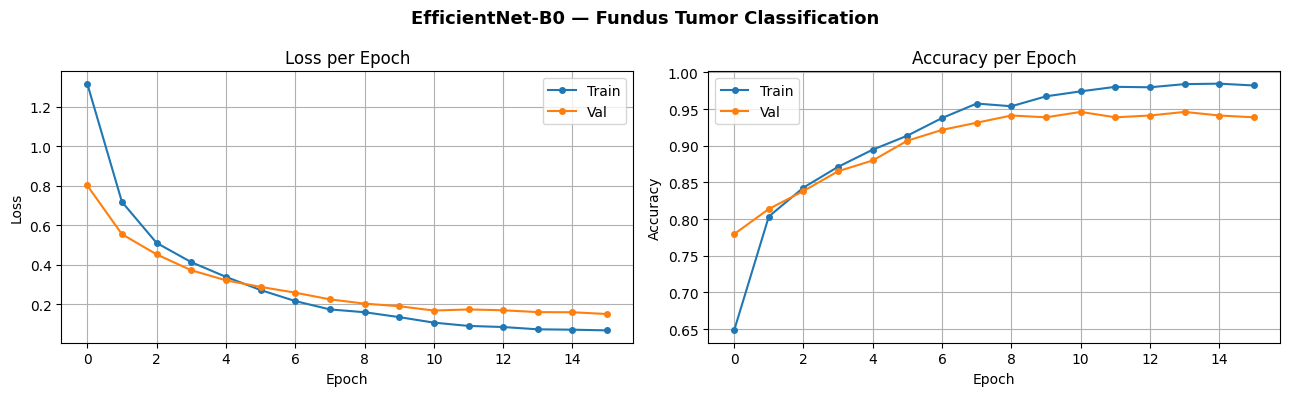

✓ Saved training_curves.png


In [8]:
# ── Cell 8: Training Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o', markersize=4)
axes[0].plot(history['val_loss'], label='Val', marker='o', markersize=4)
axes[0].set_title('Loss per Epoch');  axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss');           axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['train_acc'], label='Train', marker='o', markersize=4)
axes[1].plot(history['val_acc'], label='Val', marker='o', markersize=4)
axes[1].set_title('Accuracy per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy');          axes[1].legend(); axes[1].grid(True)

plt.suptitle('EfficientNet-B0 — Fundus Tumor Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150)
plt.show()
print('✓ Saved training_curves.png')

Final Accuracy : 94.61%

Classification Report:
                                    precision    recall  f1-score   support

         Choroidal Hemangioma (CH)       0.82      0.60      0.69        15
            Choroidal Osteoma (CO)       1.00      0.69      0.81        16
                            Normal       0.96      1.00      0.98       271
Retinal Capillary Hemangioma (RCH)       0.91      0.82      0.86        38
               Retinoblastoma (RB)       1.00      0.98      0.99        51
               Uveal Melanoma (UM)       0.70      0.82      0.76        17

                          accuracy                           0.95       408
                         macro avg       0.90      0.82      0.85       408
                      weighted avg       0.95      0.95      0.94       408



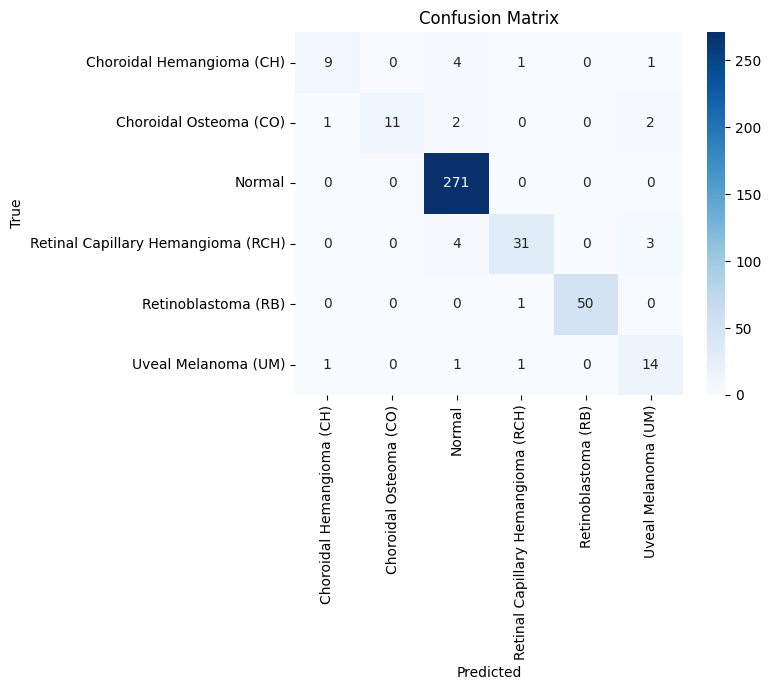

✓ Metrics saved.


In [9]:
# ── Cell 9: Evaluation — Confusion Matrix & Report ───────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Load best model
model.load_state_dict(torch.load(SAVE_DIR / 'best_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

class_names = train_dataset.classes
acc = accuracy_score(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=class_names)
cm = confusion_matrix(all_labels, all_preds)

print(f'Final Accuracy : {acc*100:.2f}%')
print('\nClassification Report:')
print(report)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Save metrics
with open(SAVE_DIR / 'metrics.txt', 'w') as f:
    f.write(f'Accuracy: {acc*100:.2f}%\n\n')
    f.write('Classification Report:\n')
    f.write(report)

print('✓ Metrics saved.')

  Class                 Correct    Total   Accuracy
  --------------------------------------------------
  Choroidal Hemangioma (CH)        9       15      60.0%
  Choroidal Osteoma (CO)       11       16      68.8%
  Normal                    271      271     100.0%
  Retinal Capillary Hemangioma (RCH)       31       38      81.6%
  Retinoblastoma (RB)        50       51      98.0%
  Uveal Melanoma (UM)        14       17      82.4%
  --------------------------------------------------
  Overall                   386      408      94.6%


/tmp/ipykernel_4407/2355873455.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10')


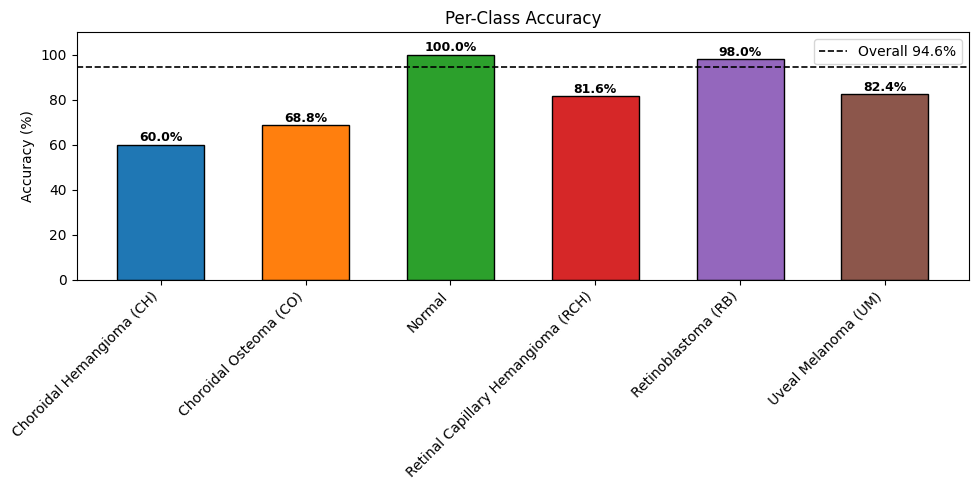

✓ Saved per_class_accuracy.png


In [10]:
# ── Cell 10: Per-Class Accuracy Bar Chart ────────────────────────────────────
import matplotlib.cm as cm

correct = {c: 0 for c in class_names}
total = {c: 0 for c in class_names}

for pred, label in zip(all_preds, all_labels):
    cls = class_names[label]
    total[cls] += 1
    correct[cls] += int(pred == label)

accs = [correct[c] / total[c] * 100 for c in class_names]
overall = sum(correct.values()) / sum(total.values()) * 100

print(f'  {"Class":<20} {"Correct":>8} {"Total":>8} {"Accuracy":>10}')
print(f'  {"-"*50}')
for cls, acc_val in zip(class_names, accs):
    print(f'  {cls:<20} {correct[cls]:>8} {total[cls]:>8} {acc_val:>9.1f}%')
print(f'  {"-"*50}')
print(f'  {"Overall":<20} {sum(correct.values()):>8} {sum(total.values()):>8} {overall:>9.1f}%')

# Generate colors
palette = cm.get_cmap('tab10')
colors = [palette(i) for i in range(len(class_names))]

plt.figure(figsize=(10, 5))
bars = plt.bar(class_names, accs, color=colors, edgecolor='black', width=0.6)
plt.axhline(overall, color='black', linestyle='--', linewidth=1.2, label=f'Overall {overall:.1f}%')
plt.ylim(0, 110); plt.ylabel('Accuracy (%)'); plt.title('Per-Class Accuracy')
plt.xticks(rotation=45, ha='right')
plt.legend()

for bar, a in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{a:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'per_class_accuracy.png', dpi=150)
plt.show()
print('✓ Saved per_class_accuracy.png')

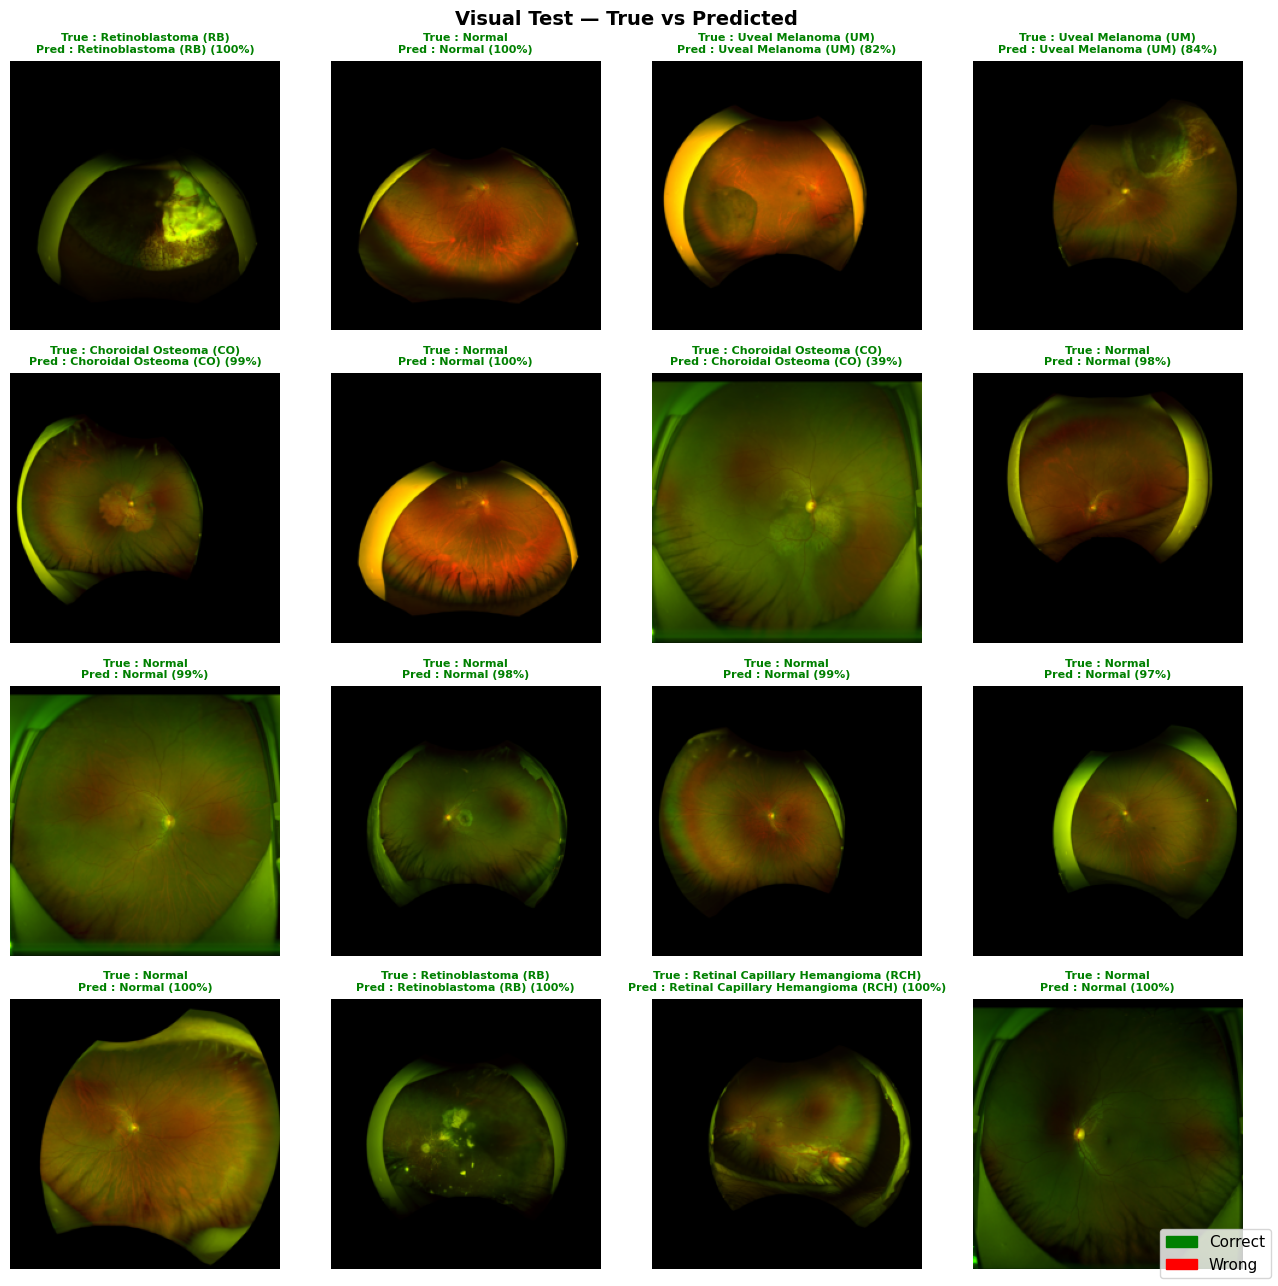

✓ Saved visual_test.png


In [11]:
# ── Cell 11: Visual Test — 16 random predictions ─────────────────────────────
import random
import matplotlib.patches as mpatches
from PIL import Image as PILImage

raw_transform = transforms.Resize((IMG_SIZE, IMG_SIZE))
indices = random.sample(range(len(val_dataset)), min(16, len(val_dataset)))

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
axes = axes.flatten()

model.eval()
for ax_idx, ds_idx in enumerate(indices):
    img_path = val_dataset.imgs[ds_idx][0]
    true_label = class_names[val_dataset.imgs[ds_idx][1]]

    tensor = val_dataset[ds_idx][0].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()
    pred_label = class_names[probs.argmax()]
    confidence = probs.max() * 100

    raw_img = raw_transform(PILImage.open(img_path).convert('RGB'))
    axes[ax_idx].imshow(raw_img)
    axes[ax_idx].axis('off')

    correct = pred_label == true_label
    color = 'green' if correct else 'red'
    axes[ax_idx].set_title(f'True : {true_label}\nPred : {pred_label} ({confidence:.0f}%)',
                           fontsize=8, color=color, fontweight='bold')

    for spine in axes[ax_idx].spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(3); spine.set_visible(True)

correct_patch = mpatches.Patch(color='green', label='Correct')
wrong_patch = mpatches.Patch(color='red', label='Wrong')
fig.legend(handles=[correct_patch, wrong_patch], loc='lower right', fontsize=11)

plt.suptitle('Visual Test — True vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'visual_test.png', dpi=150)
plt.show()
print('✓ Saved visual_test.png')

In [12]:
# ── Cell 12: Download model & results to your PC ─────────────────────────────
import shutil
from google.colab import files

# Zip everything in model_output
shutil.make_archive('/content/fundus_tumor_results', 'zip', '/content/model_output')
files.download('/content/fundus_tumor_results.zip')

print('✓ Downloaded fundus_tumor_results.zip')
print('Contents: best_model.pth, classes.json, history.json,')
print('          training_curves.png, confusion_matrix.png,')
print('          per_class_accuracy.png, visual_test.png, metrics.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded fundus_tumor_results.zip
Contents: best_model.pth, classes.json, history.json,
          training_curves.png, confusion_matrix.png,
          per_class_accuracy.png, visual_test.png, metrics.txt
